# HireGraph Walkthrough

This notebook demonstrates the HireGraph smart hiring assistant built with LangGraph.

## Overview

HireGraph is a LangGraph application that:
1. Reads a resume and job description
2. Classifies candidate seniority level using structured output (Pydantic)
3. Scores across multiple dimensions in parallel (skills, experience, education, public signals)
4. Aggregates scores with weighted reducers
5. Makes a recommendation (advance, reject, borderline)
6. Drafts a personalized email
7. Evaluates email quality with a critic LLM
8. Provides a complete audit trail of all decisions

## LangGraph Patterns Demonstrated

- **TypedDict State** - `HireGraphState` holds raw resume text, JD text, classification, scorecard, email, and audit trail
- **Structured Output** - Seniority classification uses `with_structured_output` with a Pydantic model and `Literal` types
- **Parallelization with Reducer** - Four scoring nodes fan out from classification, run concurrently, and fan in via `Annotated` reducers
- **Conditional Routing** - Decision node routes to advance, reject, or borderline terminal paths
- **Checkpointer** - `MemorySaver` wired at compile time, enabling thread-based resume
- **Audit Trail** - Every node appends to `audit_trail` using `operator.add` as a list reducer

## Setup

First, let's set up the path and environment so this notebook works from the `notebooks/` directory.

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# Ensure we can import from project root
project_root = Path(".").resolve().parent
os.chdir(project_root)
sys.path.insert(0, str(project_root))

# Load environment variables
load_dotenv()

# Check for LLM API key
if not os.getenv("OPENAI_API_KEY") and not os.getenv("ANTHROPIC_API_KEY"):
    print("Warning: No LLM API key found. Please set OPENAI_API_KEY or ANTHROPIC_API_KEY in .env")
else:
    print("LLM API key found!")
    print(f"Working directory: {os.getcwd()}")

LLM API key found!
Working directory: C:\Users\dprak\AI_Projects\hiregraph-ai


## Build the Graph

Let's build and inspect the HireGraph workflow.

In [2]:
from src.hiregraph.graph import build_graph

# Build the graph
graph = build_graph()
print("Graph built successfully!")

# Display the graph nodes
print("\nGraph nodes:")
for node in graph.nodes:
    if node != "__start__" and node != "__end__":
        print(f"  - {node}")

Graph built successfully!

Graph nodes:
  - ingest_and_parse
  - classify_seniority
  - score_skills
  - score_experience
  - score_education
  - score_public_signals
  - reduce_scores
  - make_decision
  - draft_email
  - evaluate_email
  - end_advance
  - end_reject
  - end_borderline_approved
  - end_error


## Visualize the Graph

Display the compiled graph structure.

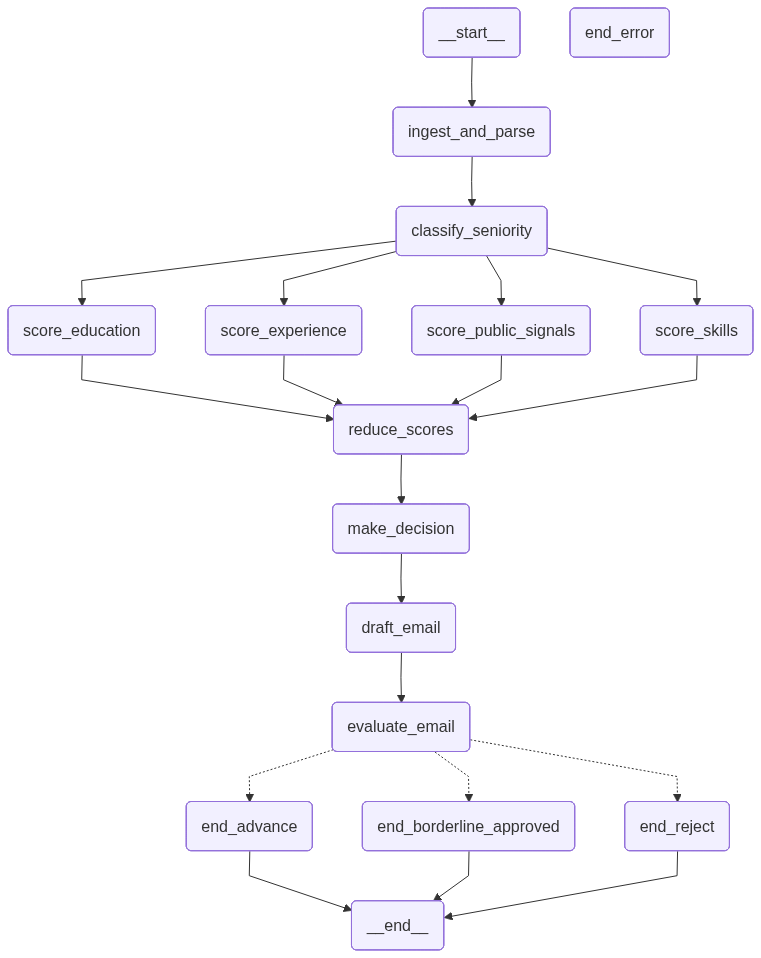

In [3]:
from IPython.display import Image, display

# Try to display the graph image
graph_path = Path("graph_out/graph.png")
if graph_path.exists():
    display(Image(filename=str(graph_path)))
else:
    # Generate it
    try:
        png_data = graph.get_graph().draw_mermaid_png()
        graph_path.parent.mkdir(exist_ok=True)
        graph_path.write_bytes(png_data)
        display(Image(data=png_data))
    except Exception as e:
        print(f"Could not render graph: {e}")
        print("Install graphviz or run main.py first to generate graph_out/graph.png")

## Load Sample Data

Let's load the sample resumes and job description shipped with the project.

In [4]:
sample_dir = Path("sample_data")

priya_resume = (sample_dir / "resumes" / "resume_priya.md").read_text()
eitan_resume = (sample_dir / "resumes" / "resume_eitan.md").read_text()
mira_resume = (sample_dir / "resumes" / "resume_mira.md").read_text()
jd = (sample_dir / "jds" / "jd_senior_backend.md").read_text()

print("Sample data loaded!")
print(f"  Resumes: Priya ({len(priya_resume)} chars), Eitan ({len(eitan_resume)} chars), Mira ({len(mira_resume)} chars)")
print(f"  JD: Senior Backend Engineer ({len(jd)} chars)")
print(f"\nJob Description preview:\n{jd[:300]}...")

Sample data loaded!
  Resumes: Priya (1838 chars), Eitan (1441 chars), Mira (1584 chars)
  JD: Senior Backend Engineer (1514 chars)

Job Description preview:
# Senior Backend Engineer

**Company:** Acme Cloud Logistics
**Location:** Remote (Americas time zones), occasional travel to NYC
**Level:** Senior (4 to 7 years)
**Compensation:** $160k to $200k base + equity

## About the role

We are building the next generation of cross-border logistics. Our bac...


## Inspect the State Schema

Let's look at the `HireGraphState` TypedDict to understand what flows through the graph.

In [5]:
from src.hiregraph.types import HireGraphState, Decision
import typing

print("HireGraphState fields:")
print("-" * 50)
for field_name, field_type in typing.get_type_hints(HireGraphState, include_extras=True).items():
    print(f"  {field_name}: {field_type}")

HireGraphState fields:
--------------------------------------------------
  resume_text: <class 'str'>
  jd_text: <class 'str'>
  seniority_level: <class 'str'>
  seniority_confidence: <class 'float'>
  resume_parsed: dict[str, typing.Any]
  jd_parsed: dict[str, typing.Any]
  skills_score: typing.Annotated[typing.Optional[dict[str, typing.Any]], <function merge_dict at 0x000002AF4D003100>]
  experience_score: typing.Annotated[typing.Optional[dict[str, typing.Any]], <function merge_dict at 0x000002AF4D003100>]
  education_score: typing.Annotated[typing.Optional[dict[str, typing.Any]], <function merge_dict at 0x000002AF4D003100>]
  public_signals_score: typing.Annotated[typing.Optional[dict[str, typing.Any]], <function merge_dict at 0x000002AF4D003100>]
  scorecard: typing.Optional[dict[str, typing.Any]]
  overall_score: typing.Optional[float]
  recommendation: <class 'str'>
  decision_reasoning: <class 'str'>
  email_draft: <class 'str'>
  email_draft_attempts: <class 'int'>
  email_dra

## Run Scenario 1: Strong Candidate (Priya)

Priya is a senior backend engineer with 8 years of Python experience, Kafka, and distributed systems. She should score high and get an **advance** recommendation.

In [6]:
# Create initial state - only raw inputs needed
initial_state: HireGraphState = {
    "resume_text": priya_resume,
    "jd_text": jd,
}

config = {"configurable": {"thread_id": "demo_priya"}}

print("Running graph for Priya (strong senior candidate)...")
print("This will make 7 LLM calls and take ~15-30 seconds.\n")

try:
    final_state = graph.invoke(initial_state, config=config)
    print("Done!")
except Exception as e:
    print(f"Error: {e}")
    print("Make sure you have set an LLM API key in your .env file")

Running graph for Priya (strong senior candidate)...
This will make 7 LLM calls and take ~15-30 seconds.

Done!


## Examine Results

In [7]:
decision = Decision(
    recommendation=final_state.get("recommendation", "reject"),
    scorecard=final_state.get("scorecard", {}),
    overall_score=final_state.get("overall_score", 0),
    email_draft=final_state.get("email_draft", ""),
    audit_trail=final_state.get("audit_trail", []),
    seniority_level=final_state.get("seniority_level", "unknown"),
    decision_reasoning=final_state.get("decision_reasoning", ""),
)

print(f"Recommendation: {decision.recommendation.upper()}")
print(f"Seniority Level: {decision.seniority_level}")
print(f"Overall Score: {decision.overall_score:.1f}/100")
print(f"Reasoning: {decision.decision_reasoning}")

Recommendation: ADVANCE
Seniority Level: senior
Overall Score: 91.4/100
Reasoning: Strong match with overall score 91.4


## Scorecard Breakdown

The scorecard shows how each parallel scoring dimension contributed.

In [8]:
print("Scorecard Breakdown:")
print("=" * 40)
if decision.scorecard.get("dimension_scores"):
    for dim, score in decision.scorecard["dimension_scores"].items():
        weight = decision.scorecard.get("weights", {}).get(dim, 0)
        print(f"  {dim:20s}: {score:5.1f}/100  (weight: {weight:.0%})")
print(f"{'':20s}  {'-----':>5}")
print(f"  {'OVERALL':20s}: {decision.overall_score:5.1f}/100")

Scorecard Breakdown:
  skills              :  95.0/100  (weight: 35%)
  experience          :  92.0/100  (weight: 35%)
  education           :  85.0/100  (weight: 15%)
  public_signals      :  88.0/100  (weight: 15%)
                      -----
  OVERALL             :  91.4/100


## Email Draft

In [9]:
print("Email Draft:")
print("-" * 60)
print(decision.email_draft)
print("-" * 60)

Email Draft:
------------------------------------------------------------
Dear Priya,

I hope this message finds you well! I wanted to personally reach out to let you know that we were thoroughly impressed by your extensive experience as a Senior Backend Engineer, especially your impressive work at Pelican Freight, where you successfully owned the shipment-events service and led a team through a major replatforming project with zero downtime. Your contributions to improving on-call processes and your mentoring of engineers caught our attention, aligning perfectly with what we're looking for at Acme Cloud Logistics.

We are excited to invite you to move forward with your application and schedule a technical interview. Your skills in Python, experience with Kafka, and understanding of distributed systems will be invaluable as we build critical services to handle millions of shipment events across our platform. Please let us know your availability for a conversation in the coming days, as

## Audit Trail

Every node records its execution time and verdict.

In [10]:
print(f"Audit Trail ({len(decision.audit_trail)} node executions):")
print(f"{'Node':<25} {'Verdict':<10} {'Duration':>10}")
print("-" * 50)
total_ms = 0
for entry in decision.audit_trail:
    dur = entry['duration_ms']
    total_ms += dur
    print(f"  {entry['node']:<23} {entry['verdict']:<10} {dur:>8.1f}ms")
print("-" * 50)
print(f"  {'TOTAL':<23} {'':10} {total_ms:>8.1f}ms")

Audit Trail (11 node executions):
Node                      Verdict      Duration
--------------------------------------------------
  ingest_and_parse        success         1.0ms
  classify_seniority      success      3236.1ms
  score_education         success      1941.6ms
  score_experience        success      4454.6ms
  score_public_signals    success      3665.9ms
  score_skills            success      3912.1ms
  reduce_scores           success         0.0ms
  make_decision           success         0.0ms
  draft_email             success      4254.3ms
  evaluate_email          success      2057.8ms
  end_advance             success         0.0ms
--------------------------------------------------
  TOTAL                               23523.5ms


## Run All Three Scenarios

Let's compare the results across all three sample candidates:
- **Priya** - Strong senior backend (should advance)
- **Mira** - Frontend engineer applying for backend role (should reject)
- **Eitan** - Mid-level with potential (borderline/reject for senior role)

In [11]:
def run_scenario(graph, resume_text, jd_text, candidate_name):
    """Run a single scenario through the graph."""
    initial_state: HireGraphState = {
        "resume_text": resume_text,
        "jd_text": jd_text,
    }
    config = {"configurable": {"thread_id": f"demo_{candidate_name}"}}
    
    try:
        final_state = graph.invoke(initial_state, config=config)
        return Decision(
            recommendation=final_state.get("recommendation", "reject"),
            scorecard=final_state.get("scorecard", {}),
            overall_score=final_state.get("overall_score", 0),
            email_draft=final_state.get("email_draft", ""),
            audit_trail=final_state.get("audit_trail", []),
            seniority_level=final_state.get("seniority_level", "unknown"),
            decision_reasoning=final_state.get("decision_reasoning", ""),
        )
    except Exception as e:
        print(f"Error processing {candidate_name}: {e}")
        return None

# Run remaining scenarios (Priya already ran above)
print("Running Mira (frontend mismatch)...")
mira_decision = run_scenario(graph, mira_resume, jd, "mira")
print(f"  -> {mira_decision.recommendation} ({mira_decision.overall_score:.1f})\n")

print("Running Eitan (borderline mid-level)...")
eitan_decision = run_scenario(graph, eitan_resume, jd, "eitan")
print(f"  -> {eitan_decision.recommendation} ({eitan_decision.overall_score:.1f})")

Running Mira (frontend mismatch)...
  -> reject (17.0)

Running Eitan (borderline mid-level)...
  -> reject (50.8)


## Scoreboard Summary

In [12]:
results = [
    ("Priya (Strong Senior)", decision),
    ("Mira (Frontend Mismatch)", mira_decision),
    ("Eitan (Borderline Mid)", eitan_decision),
]

print("=" * 65)
print("SCOREBOARD SUMMARY")
print("=" * 65)
print(f"{'Candidate':<30} {'Recommendation':<15} {'Score':>8} {'Seniority':<10}")
print("-" * 65)
for name, d in results:
    if d:
        print(f"  {name:<28} {d.recommendation:<15} {d.overall_score:>6.1f}  {d.seniority_level:<10}")
print("=" * 65)

SCOREBOARD SUMMARY
Candidate                      Recommendation     Score Seniority 
-----------------------------------------------------------------
  Priya (Strong Senior)        advance           91.4  senior    
  Mira (Frontend Mismatch)     reject            17.0  senior    
  Eitan (Borderline Mid)       reject            50.8  junior    


## Key Observations

From the results above:

1. **Priya** scores high across all dimensions - strong backend match, gets **advance**
2. **Mira** scores low - she is a frontend engineer applying for a backend role, gets **reject**
3. **Eitan** is in between - has potential but only 2 years experience for a senior role

## Architecture Notes

- The graph makes **7 LLM calls per candidate** (classify + 4 scores + draft + evaluate)
- Parallel scoring nodes run concurrently, visible in the audit trail timestamps
- The `Annotated` reducers on state keys handle concurrent writes safely
- The `MemorySaver` checkpointer enables resuming runs by `thread_id`
- State holds only raw data - all prompts are constructed inside nodes